## Amazaon sales dataset analysis and product success predictor

### Objective:
### The goal of this project is to analyze an Amazon product dataset to extract meaningful insights about:
### Pricing strategies (actual vs discounted price)
### Customer satisfaction (ratings and reviews)
### Product performance across categories
### predict a particular models success in market before launch

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
# Convert price columns to numeric (remove ₹ and commas if present)
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)


In [4]:
# Convert discount percentage
df['discount_percentage'] = df['discount_percentage'].replace('%', '', regex=True).astype(float)

In [5]:
# Convert rating and rating_count
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

In [6]:
df.dropna(subset=['rating', 'discounted_price'], inplace=True)

In [7]:
# Calculate savings
df['savings'] = df['actual_price'] - df['discounted_price']

In [13]:
# Top categories
top_categories = df['category'].value_counts().head(5)

In [14]:
avg_rating = df['rating'].mean()

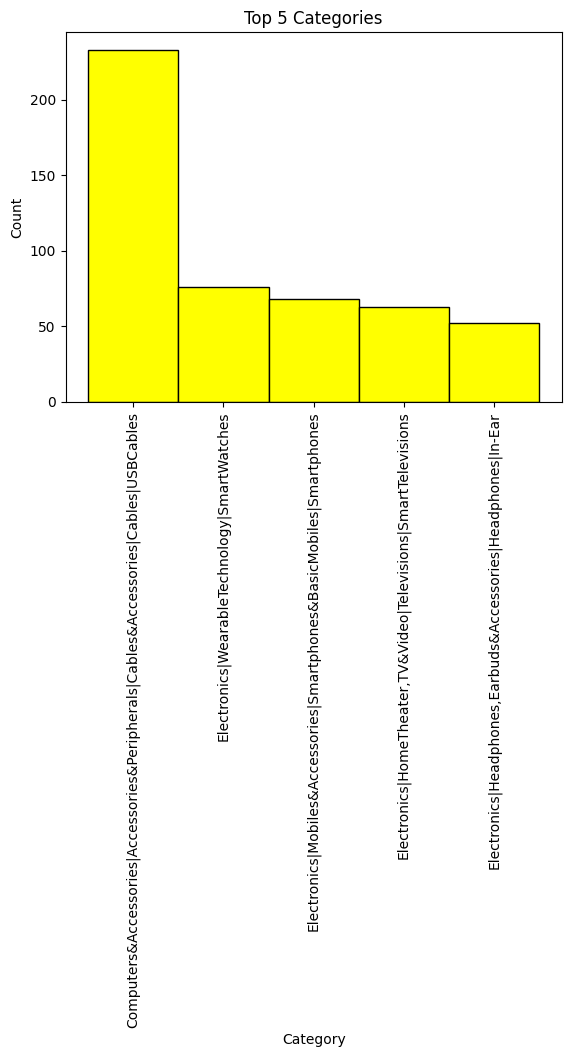

In [24]:
# 1. Top Categories
top_categories.plot(kind='bar',color='yellow',edgecolor='black',width=1)

plt.title("Top 5 Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

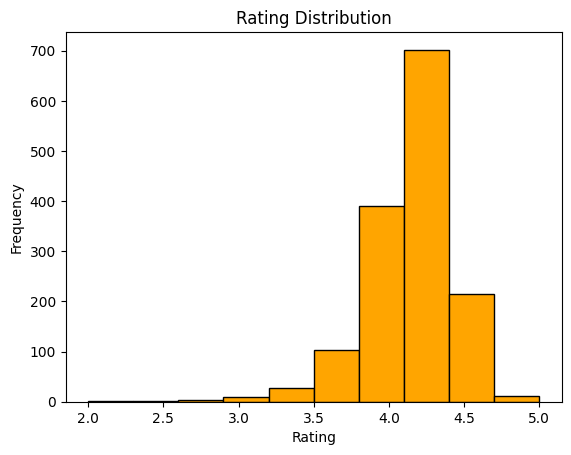

In [27]:
# 2. Rating Distribution
plt.hist(df['rating'], bins=10,color='orange',edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

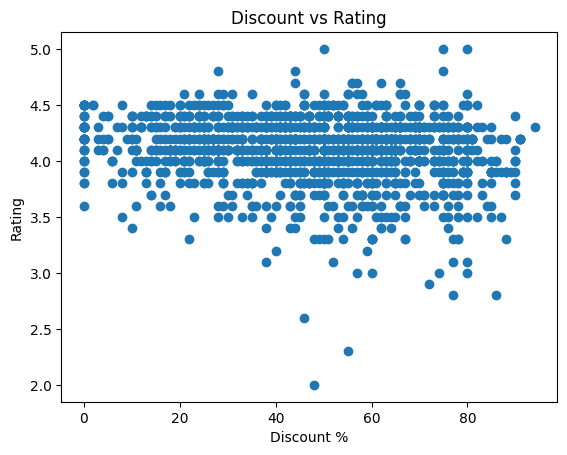

In [28]:
# 3. Discount vs Rating
plt.scatter(df['discount_percentage'], df['rating'])
plt.title("Discount vs Rating")
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.show()

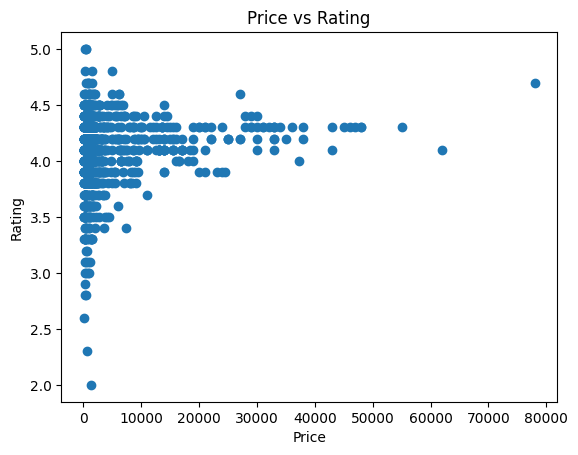

In [29]:
# 4. Price vs Rating
plt.scatter(df['discounted_price'], df['rating'])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [30]:
# Step 6: Print Insights

print("Average Rating:", avg_rating)
print("Top Categories:\n", top_categories)

Average Rating: 4.096584699453552
Top Categories:
 category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables    233
Electronics|WearableTechnology|SmartWatches                                           76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                  68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                         63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                          52
Name: count, dtype: int64


### You will observe:

### Some categories dominate sales
### Most ratings are between 3.5 to 4.5
### Discount does not always increase rating
### Expensive products don’t always have better ratings

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [32]:
X = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']]
y = df['rating']

In [33]:
X = X.fillna(X.mean())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [34]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [35]:
print("\n--- MODEL EVALUATION ---")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


--- MODEL EVALUATION ---
Mean Absolute Error: 0.20660641729137744
R2 Score: 0.04229686702289148


In [38]:
sample = [[500, 1000, 50, 2000]]  # [discounted_price, actual_price, discount%, rating_count]
predicted_rating = model.predict(sample)

print("\nPredicted Rating for sample product:\n", predicted_rating[0])


Predicted Rating for sample product:
 4.35180407002313


C:\Users\Devavrat Surve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
